**Introduction**

The objective of this task is to apply K-Means Clustering on the Mall Customers dataset to identify distinct customer segments based on their annual income and spending behavior. This helps in understanding different groups of customers and enables businesses to design targeted marketing strategies.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA




In [ ]:

url = "https://raw.githubusercontent.com/sharmaroshan/Clustering-of-Mall-Customers/master/Mall_Customers.csv"
df = pd.read_csv(url)



In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
df['y'].value_counts()

(41188, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   411

,count
y,
0,36548
1,4640


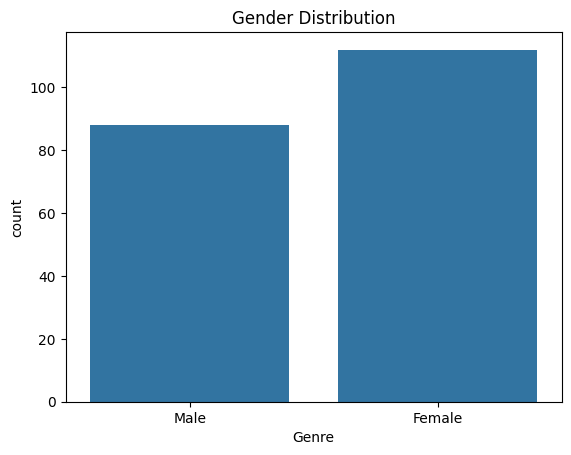

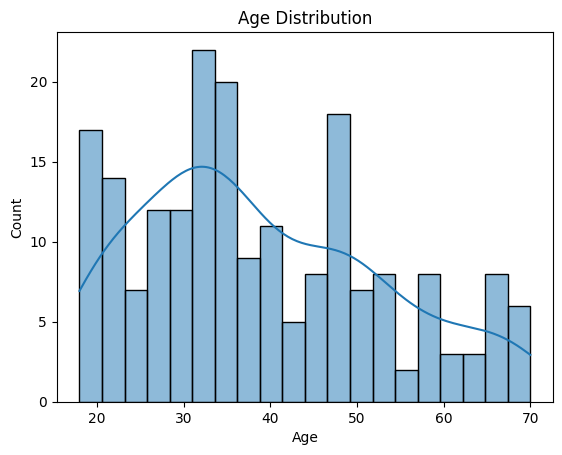

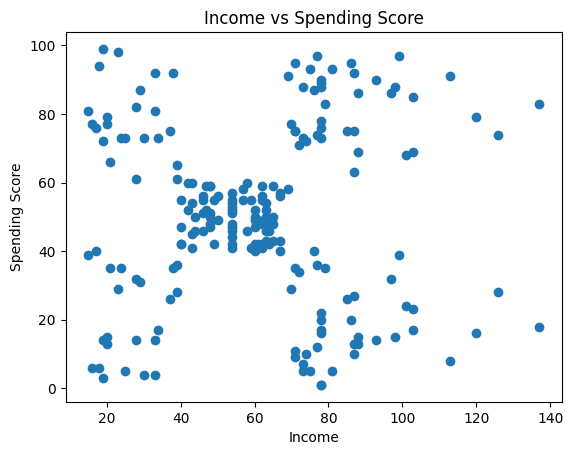

In [ ]:

sns.countplot(x='Genre', data=df)
plt.title("Gender Distribution")
plt.show()
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")
plt.show()

In [ ]:

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

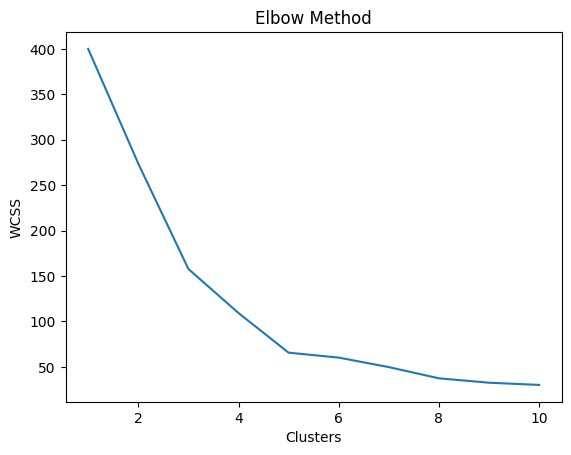

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

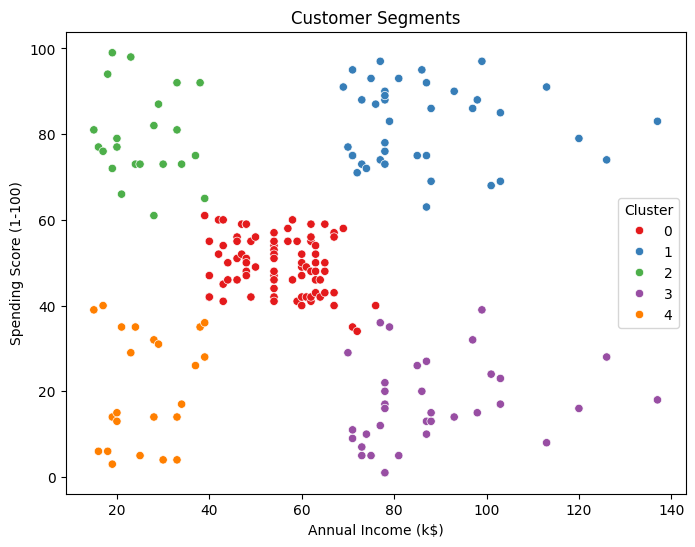

In [ ]:

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set1')

plt.title("Customer Segments")
plt.show()

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]


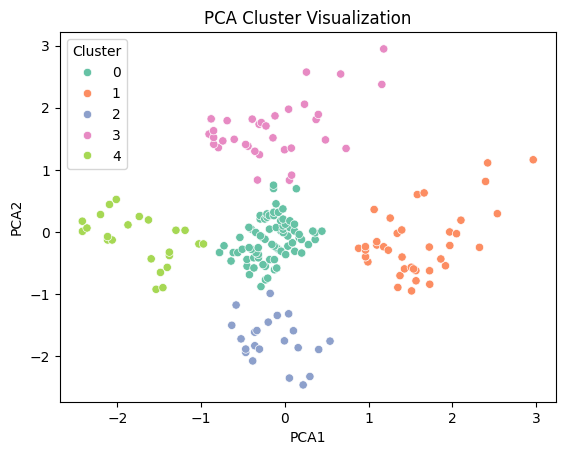

In [ ]:

sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set2')
plt.title("PCA Cluster Visualization")
plt.show()

In [ ]:
df.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),PCA1,PCA2
Cluster,,,,,,
0,86.320988,42.716049,55.296296,49.518519,-0.160774,-0.123359
1,162.000000,32.692308,86.538462,82.128205,1.577616,-0.175306
2,23.090909,25.272727,25.727273,79.363636,-0.139560,-1.740701
3,164.371429,41.114286,88.200000,17.114286,-0.162236,1.654235
4,23.000000,45.217391,26.304348,20.913043,-1.728511,-0.120599


**Conclusion**

In this project, K-Means clustering was applied to group customers into five different segments based on their income and spending patterns.

The analysis highlighted that:

Some customers have both high income and high spending, making them the most valuable segment for the business
Some customers have high income but relatively low spending, showing potential for growth through targeted strategies
Other customers fall into the low income and low spending category, requiring more cost-effective approaches

This segmentation helps businesses to:

Create more targeted and effective marketing campaigns
Enhance customer satisfaction
And ultimately improve overall profitability

